In [1]:
from collections import Counter

In [2]:
import sys

In [3]:
sys.path.append('../')

In [4]:
import my_functions

In [5]:
from sklearn.ensemble import RandomForestClassifier

In [6]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [7]:
from imblearn.datasets import fetch_datasets

In [10]:
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE,
    SVMSMOTE
)

In [ ]:
oversampler_dict = {
    'random': RandomOverSampler(
    sampling_strategy='auto',
    random_state=0,
),
    'smote': SMOTE(sampling_strategy='auto', random_state=0, k_neighbors=5),
    'adasyn': ADASYN(sampling_strategy='auto', random_state=0, n_neighbors=5),
    'border1': BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
),
    'border2': BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-2',
),
    'svm': SVMSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
    m_neighbors=10,
    svm_estimator=SVC(kernel='linear'),
    out_step=0.5,
)}

In [36]:
datasets_ls = [
    'car_eval_34',
    'ecoli',
    'thyroid_sick',
    'arrhythmia',
    'ozone_level']


In [37]:
for dataset in datasets_ls:
    data = fetch_datasets()[dataset]
    print(dataset)
    print(Counter(data.target))
    print()

car_eval_34
Counter({np.int64(-1): 1594, np.int64(1): 134})

ecoli
Counter({np.int64(-1): 301, np.int64(1): 35})

thyroid_sick
Counter({np.int64(-1): 3541, np.int64(1): 231})

arrhythmia
Counter({np.int64(-1): 427, np.int64(1): 25})

ozone_level
Counter({np.int64(-1): 2463, np.int64(1): 73})



In [30]:
import imblearn.datasets

In [31]:
for item in dir(imblearn.datasets):
    if 'data' in item.lower():
        print(item)

fetch_datasets


In [33]:
for item in fetch_datasets().keys():
    print(item)

ecoli
optical_digits
satimage
pen_digits
abalone
sick_euthyroid
spectrometer
car_eval_34
isolet
us_crime
yeast_ml8
scene
libras_move
thyroid_sick
coil_2000
arrhythmia
solar_flare_m0
oil
car_eval_4
wine_quality
letter_img
yeast_me2
webpage
ozone_level
mammography
protein_homo
abalone_19


In [27]:
?SVMSMOTE

Init signature:
SVMSMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
    m_neighbors=10,
    svm_estimator=None,
    out_step=0.5,
)
Docstring:     
Over-sampling using SVM-SMOTE.

Variant of SMOTE algorithm which use an SVM algorithm to detect sample to
use for generating new synthetic samples as proposed in [2]_.

Read more in the :ref:`User Guide <smote_adasyn>`.

.. versionadded:: 0.4

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

    

In [26]:
for item in dir(imblearn.over_sampling):
    if 'svm' in item.lower():
        print(item)

SVMSMOTE


In [22]:
import imblearn.over_sampling

In [38]:
def run_randomForests(X_train, X_test, y_train, y_test):

    rf = RandomForestClassifier(
        n_estimators=100, random_state=0, max_depth=2, n_jobs=-1
    )
    rf.fit(X_train, y_train)

    print('Train set')
    pred = rf.predict_proba(X_train)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred)))

    print('Test set')
    pred = rf.predict_proba(X_test)[:,1]
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, pred)))

    return roc_auc_score(y_test, pred)

In [42]:
results_dict = {}
shapes_dict = {}

for dataset in datasets_ls:

    results_dict[dataset] = {}
    shapes_dict[dataset] = {}

    print(dataset)

    #Load dataset
    data = fetch_datasets()[dataset]

    # separate train and test
    X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=0)

    #as some oversampling techniques us KNN
    #we set variables in the same scale
    scaler = MinMaxScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    roc = run_randomForests(X_train, X_test, y_train, y_test)

    #store results
    results_dict[dataset]['full_data'] = roc
    shapes_dict[dataset]['full_data'] = len(X_train)

    print()

    for oversampler in oversampler_dict.keys():
        print(oversampler)

        #resample
        X_resampled, y_resampled = oversampler_dict[oversampler].fit_resample(X_train, y_train)

        #evaluate performance
        roc = run_randomForests(X_resampled, X_test, y_resampled, y_test)

        #store results
        results_dict[dataset][oversampler] = roc
        shapes_dict[dataset][oversampler] = len(X_resampled)
        print()

    print()

car_eval_34
Train set
Random Forests roc-auc: 0.9570085173623155
Test set
Random Forests roc-auc: 0.9430299010103071

random
Train set
Random Forests roc-auc: 0.9834161142585527
Test set
Random Forests roc-auc: 0.9751250127564037

smote
Train set
Random Forests roc-auc: 0.986225928495266
Test set
Random Forests roc-auc: 0.9710684763751404

adasyn
Train set
Random Forests roc-auc: 0.9863137530554607
Test set
Random Forests roc-auc: 0.9729564241249107

border1
Train set
Random Forests roc-auc: 0.9873837373620586
Test set
Random Forests roc-auc: 0.9794621900193897

border2
Train set
Random Forests roc-auc: 0.9901907413830757
Test set
Random Forests roc-auc: 0.9875497499744872

svm
Train set
Random Forests roc-auc: 0.9854760023637928
Test set
Random Forests roc-auc: 0.9717573221757323


ecoli
Train set
Random Forests roc-auc: 0.9753404490246596
Test set
Random Forests roc-auc: 0.9420289855072463

random
Train set
Random Forests roc-auc: 0.9712231862823654
Test set
Random Forests roc-auc: 0

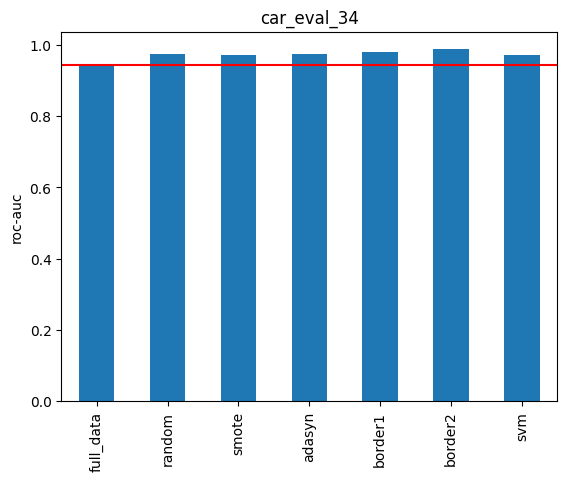

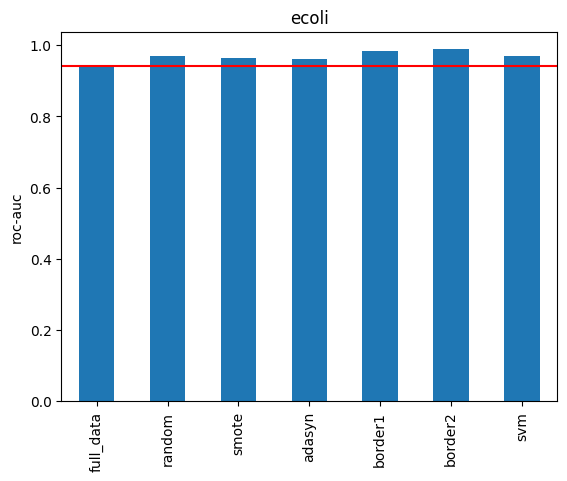

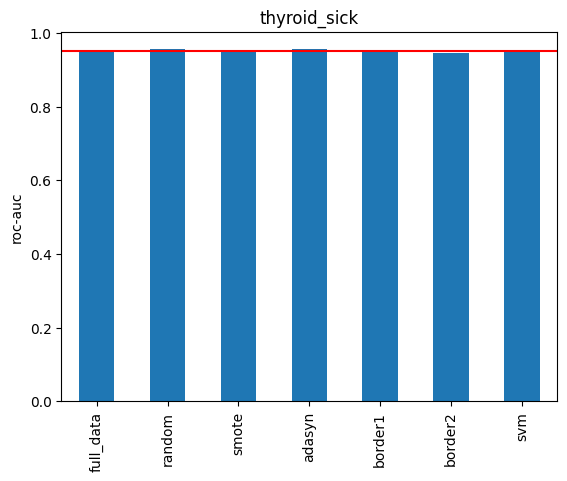

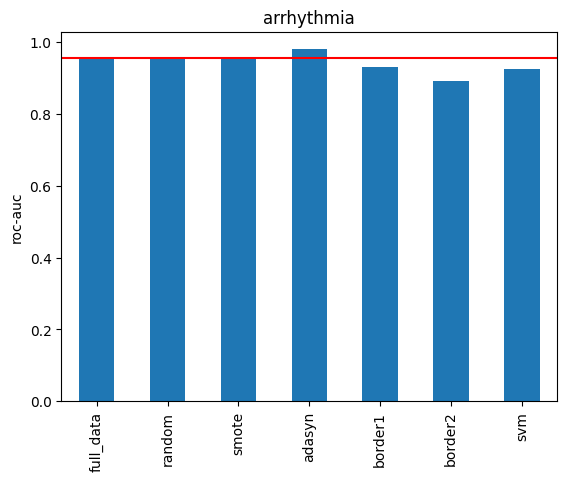

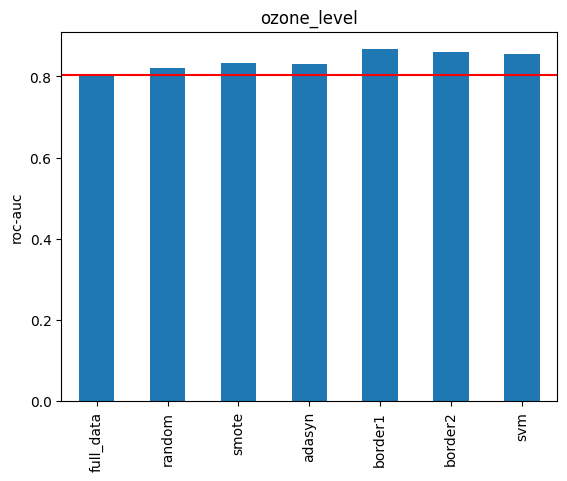

In [47]:
for dataset in datasets_ls:
    pd.Series(results_dict[dataset]).plot.bar()
    plt.title(dataset)
    plt.ylabel('roc-auc')
    plt.axhline(results_dict[dataset]['full_data'], color='r')
    plt.show()

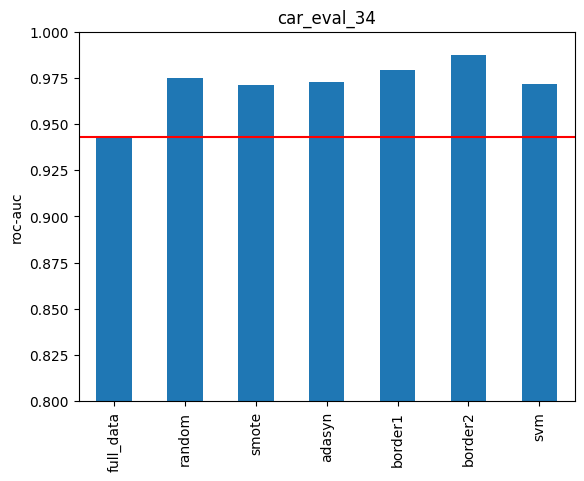

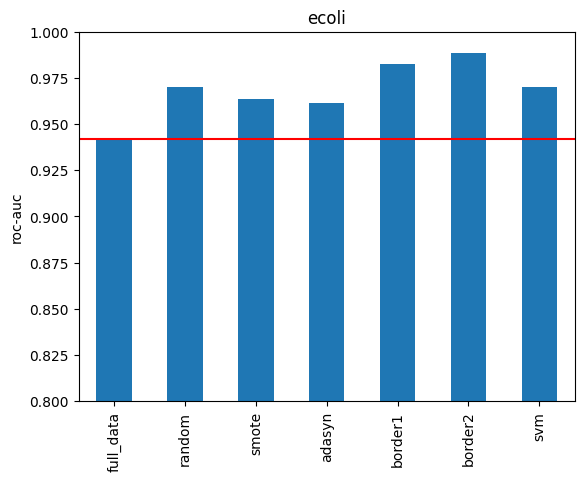

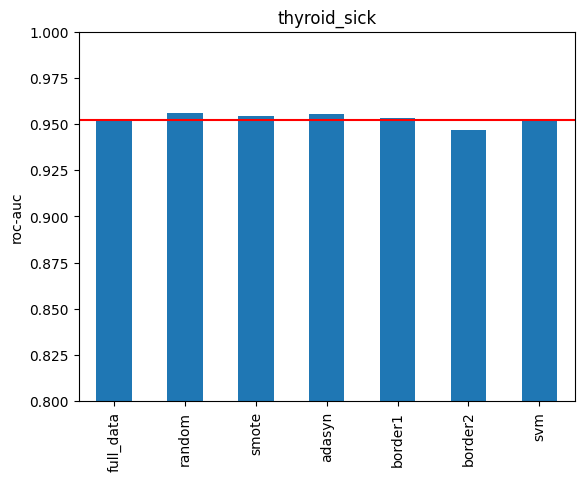

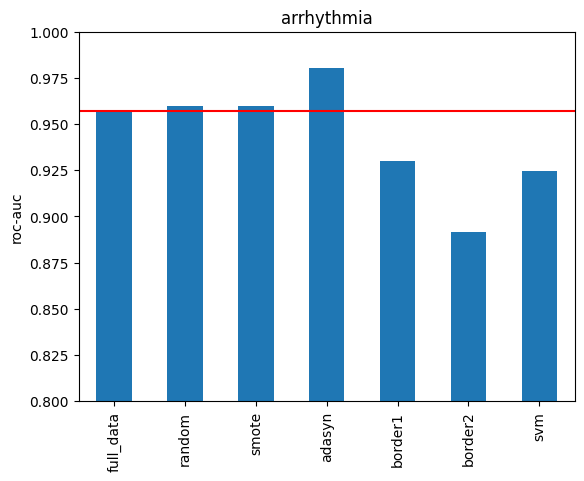

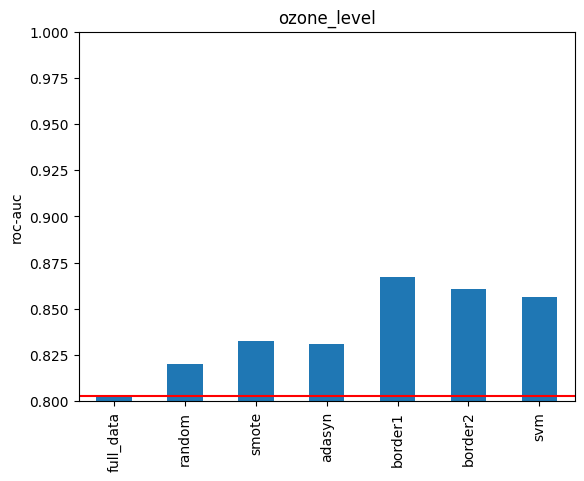

In [49]:
for dataset in datasets_ls:

    pd.Series(results_dict[dataset]).plot.bar()
    plt.title(dataset)
    plt.ylabel('roc-auc')
    plt.ylim(0.8,1)
    plt.axhline(results_dict[dataset]['full_data'], color='r')
    plt.show()

# Different over-sampling techniques work better in different datasets.

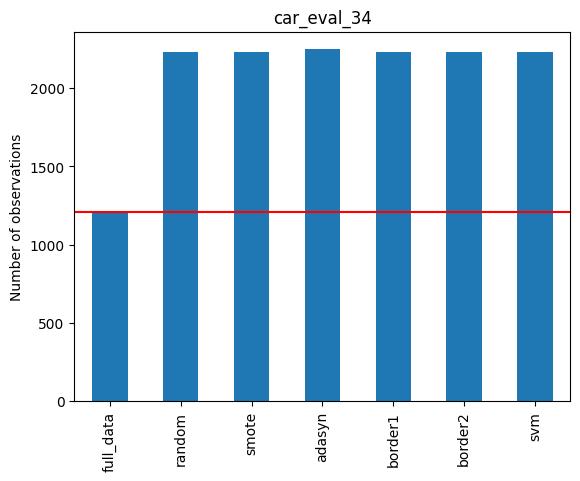

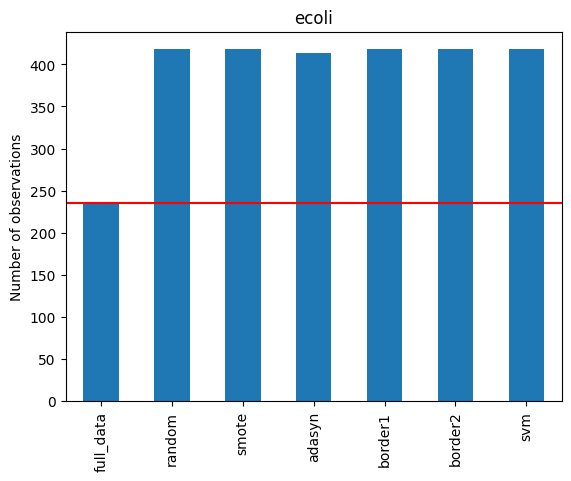

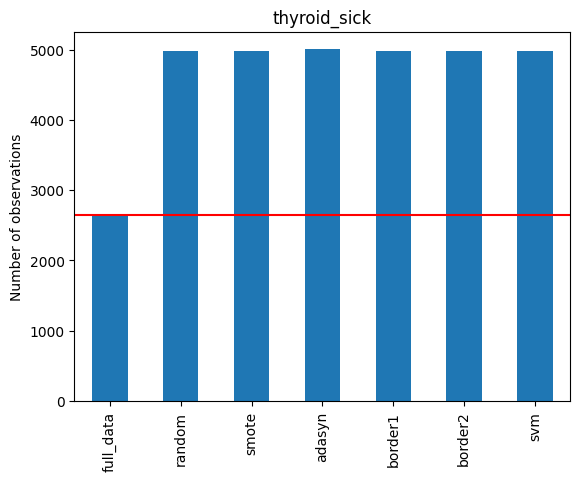

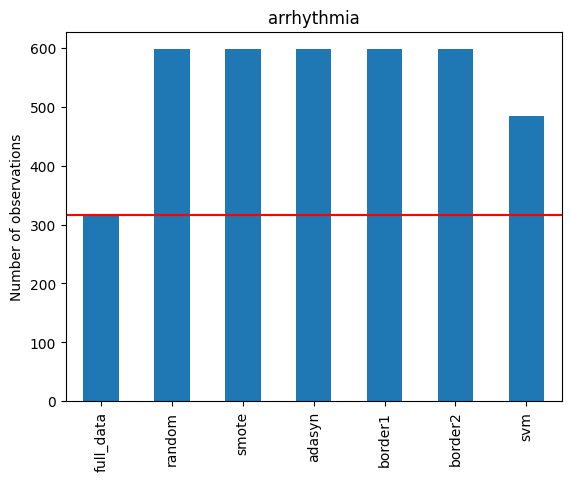

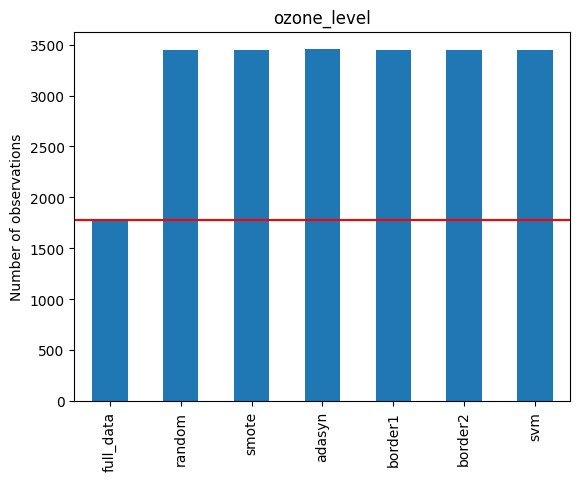

In [51]:
for dataset in datasets_ls:

    pd.Series(shapes_dict[dataset]).plot.bar()
    plt.title(dataset)
    plt.ylabel('Number of observations')
    plt.axhline(shapes_dict[dataset]['full_data'], color='r')
    plt.show()